In [2]:
import pandas as pd
import seaborn as sns
import scipy

ka_ks_7.py and dn_ds.py were used on the cantabrian and the french set of populations. No of heterozygous sites in the outgroup and the multiallelic sites was calculated and these sites were skipped and not included in the calculations

# Cantabrians

In [4]:
#After running this we will get ka_ks_7.py we get a file which should look like
output=pd.read_csv("N:/dep_coupland/grp_fulgione/mehak/software/ka_ks/canta_france_mont_a/output_kaks_7_cantabria_mont_a.txt",sep="\t", header=None)

In [5]:
output.columns=["chr","pos","daf_non_syn","daf_syn","gene","ns","ps"]

In [6]:
output

,chr,pos,daf_non_syn,daf_syn,gene,ns,ps
0,chr1,11194,0,0,AA1G01010,n,p
1,chr1,11200,0,0,AA1G01010,s,p
2,chr1,11201,0,0,AA1G01010,s,p
3,chr1,11228,0,0,AA1G01010,s,p
4,chr1,11230,14,0,AA1G01010,n,p
...,...,...,...,...,...,...,...
4305413,chr8,49782860,0,0,AA8G55280,s,p
4305414,chr8,49782866,0,0,AA8G55280,s,p
4305415,chr8,49782878,0,0,AA8G55280,s,p
4305416,chr8,49782881,0,0,AA8G55280,s,p


here the columns 1 ans 2 represent the position of the snp. the columns daf_non_syn and daf_syn have the derived allele frequency it is in the daf_non_syn column if the mutation is non synonymous and is in the daf_syn column if it is synonymous. gene colun tells about the gene it belo0ngs to. the ns column tells if the mutation is synonymous or no0n synonymous. the ps column tells if the mutation is polymorphic or it is substitution.

now we need to calculate the number of synonymous and non sysnonymous mutations per gene. but before that there are some records with which has daf zero in both non_syn and syn. therse can be due to 2 cases:
1 missing data. in all samples present in our vcf the genotype information is absent. that is ./.
2 when all the genotypes are anc-this will be only the case when our snp is a polymorphism.

we will count the number of non syn and syn substitutions and polymorphisms. we will exclude the missing sites it will have the frequencies zero and zero. And we will also remove sites which are fixed ancestral (because it is then not a polymorphism).
these we will do with another piece of code that takes the above file as inputs and returns the counts of non synonymous and synonymous sites per gene. below is the code

After running this we should have something in the file below

## dn/ds

In [13]:
result=pd.read_csv("N:/dep_coupland/grp_fulgione/mehak/software/ka_ks/canta_france_mont_a/dn_ds_2_cantabria_mont_a_ka_ks7.txt",sep="\t")

In [14]:
result

,gene,Dn,Ds,Pn,Ps
0,AA1G01010,5,8,38,14
1,AA1G01020,7,7,5,9
2,AA1G01030,3,4,4,3
3,AA1G01040,4,8,2,8
4,AA1G01050,18,18,26,11
...,...,...,...,...,...
28740,AA8G55260,2,0,1,0
28741,AA8G55270,0,8,1,6
28742,AA8G55280,12,8,9,6
28743,AA8G55290,3,2,8,4


now we have the raw counts of polimorphisms and substitutions. We need to divide it by the number of non synonymous and synonymous sites. I calculated those by a software called ddegenotate

In [15]:
df=pd.read_csv("N:/dep_coupland/grp_fulgione/mehak/software/ka_ks/degenotate_output/transcript-counts.tsv",sep="\t")

In [16]:
df

,transcript,gene,cds_length,mrna_length,is_longest,f0,f2,f3,f4
0,AAs810T01010.1,AAs810G01010,1098,1669,yes,705,228,23,142
1,AA1T01010.1,AA1G01010,2019,4168,yes,1299,379,45,296
2,AA1T01020.1,AA1G01020,1887,3083,yes,1242,315,36,294
3,AA1T01030.1,AA1G01030,624,798,yes,404,115,8,97
4,AA1T01040.1,AA1G01040,1095,1351,yes,726,156,21,192
...,...,...,...,...,...,...,...,...,...
35276,AAs982T01010.4,AAs982G01010,810,4919,yes,513,181,16,100
35277,AAs982T01010.5,AAs982G01010,810,4919,no,513,181,16,100
35278,AAs1006T01010.1,AAs1006G01010,1500,1499,yes,962,283,26,229
35279,AAs1032T01010.1,AAs1032G01010,642,1896,yes,406,145,10,81


In [17]:
gene=[]
Nc=[]
Sc=[]
for i in range(len(df)):
    if df["gene"][i] not in gene:
        nc=df["f0"][i]+(2/3)*df["f2"][i]+(1/3)*df["f3"][i]
        sc=(1/3)*df["f2"][i]+(2/3)*df["f3"][i]+df["f4"][i]
        Nc.append(nc)
        Sc.append(sc)
        gene.append(df["gene"][i])

In [18]:
sites=pd.DataFrame({"gene":gene, "Nc":Nc, "Sc":Sc})

In [19]:
calc1=pd.merge(result,sites, on="gene")

This is how the distribution of dn/ds looks in Cnatabria

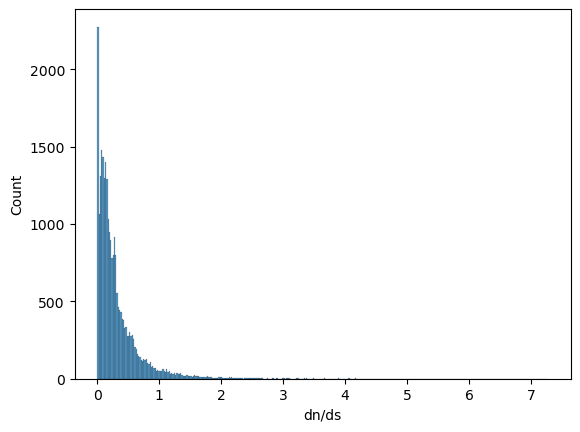

In [20]:
calc1["dn"]=calc1["Dn"]/calc1["Nc"]
calc1["ds"]=calc1["Ds"]/calc1["Sc"]
calc1["dn/ds"]=calc1["dn"]/calc1["ds"]
ax=sns.histplot(data=calc1["dn/ds"])

<Axes: ylabel='dn/ds'>

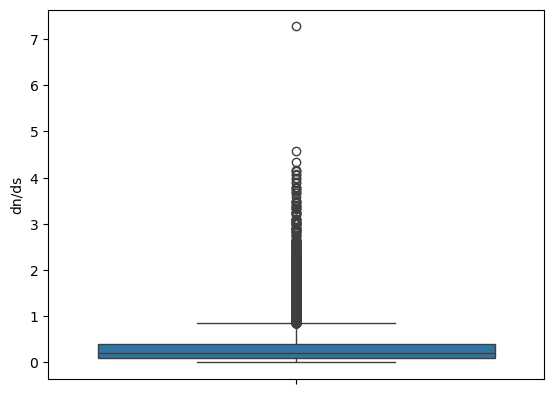

In [21]:
sns.boxplot(data=calc1["dn/ds"])

In [22]:
import numpy as np

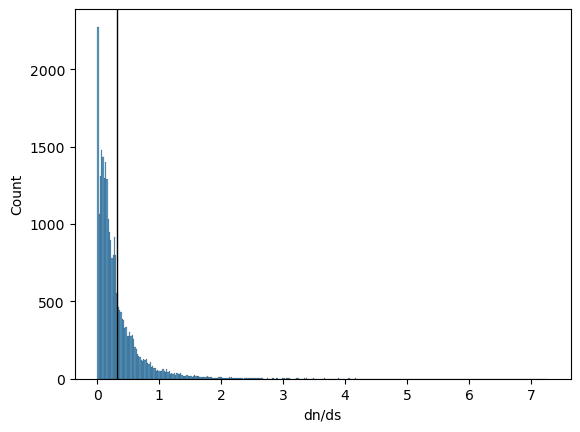

In [23]:
ax=sns.histplot(data=calc1["dn/ds"])
ax.axvline(np.ma.masked_invalid(calc1["dn/ds"]).mean(), color='black', lw=1)

In [24]:
np.ma.masked_invalid(calc1["dn/ds"]).mean()

0.31353799770307045

In [26]:
cantabria_calc1=calc1

In [25]:
calc1

,gene,Dn,Ds,Pn,Ps,Nc,Sc,dn,ds,dn/ds
0,AA1G01010,5,8,38,14,1566.666667,452.333333,0.003191,0.017686,0.180452
1,AA1G01020,7,7,5,9,1464.000000,423.000000,0.004781,0.016548,0.288934
2,AA1G01030,3,4,4,3,483.333333,140.666667,0.006207,0.028436,0.218276
3,AA1G01040,4,8,2,8,837.000000,258.000000,0.004779,0.031008,0.154122
4,AA1G01050,18,18,26,11,169.666667,46.333333,0.106090,0.388489,0.273084
...,...,...,...,...,...,...,...,...,...,...
28725,AA8G55260,2,0,1,0,511.333333,151.666667,0.003911,0.000000,inf
28726,AA8G55270,0,8,1,6,892.000000,293.000000,0.000000,0.027304,0.000000
28727,AA8G55280,12,8,9,6,1258.333333,358.666667,0.009536,0.022305,0.427550
28728,AA8G55290,3,2,8,4,909.333333,254.666667,0.003299,0.007853,0.420088


Now we have the distribution of dn/ds. SO the genes with dn/ds ==1 atr the ones that are completely neutral. dn/ds >1  ensures that there is some positive selection. and dn/ds<1 ensures that there is atlest some puryfing slection. It is hard to gauge what might be the percentage be we can say id the dn/ds==0.9 for example there are atleast 0.1 mutations that are negative there can be more. 

In [67]:
cantabria_calc1.to_csv("N:/dep_coupland/grp_fulgione/mehak/software/ka_ks/canta_france_mont_a/cantabria_calc.txt",sep="\t",index=False)

## France

In [27]:
result=pd.read_csv("N:/dep_coupland/grp_fulgione/mehak/software/ka_ks/canta_france_mont_a/dn_ds_2_france_mont_a_ka_ks7.txt",sep="\t")

In [28]:
calc1=pd.merge(result,sites, on="gene")

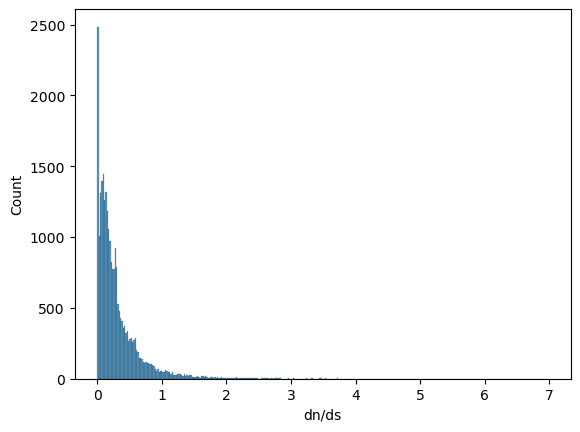

In [29]:
calc1["dn"]=calc1["Dn"]/calc1["Nc"]
calc1["ds"]=calc1["Ds"]/calc1["Sc"]
calc1["dn/ds"]=calc1["dn"]/calc1["ds"]
ax=sns.histplot(data=calc1["dn/ds"])

<Axes: ylabel='dn/ds'>

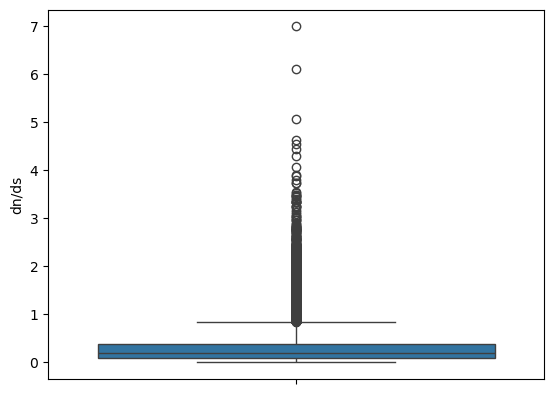

In [30]:
sns.boxplot(data=calc1["dn/ds"])

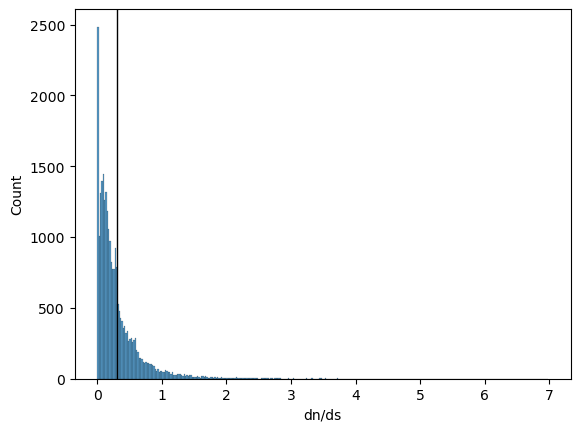

In [31]:
ax=sns.histplot(data=calc1["dn/ds"])
ax.axvline(np.ma.masked_invalid(calc1["dn/ds"]).mean(), color='black', lw=1)

In [32]:
np.ma.masked_invalid(calc1["dn/ds"]).mean()

0.30750985203795383

In [33]:
france_calc1=calc1

In [34]:
calc1

,gene,Dn,Ds,Pn,Ps,Nc,Sc,dn,ds,dn/ds
0,AA1G01010,4,5,31,21,1566.666667,452.333333,0.002553,0.011054,0.230979
1,AA1G01020,6,7,2,4,1464.000000,423.000000,0.004098,0.016548,0.247658
2,AA1G01030,3,4,1,0,483.333333,140.666667,0.006207,0.028436,0.218276
3,AA1G01040,3,9,3,3,837.000000,258.000000,0.003584,0.034884,0.102748
4,AA1G01050,17,18,7,9,169.666667,46.333333,0.100196,0.388489,0.257913
...,...,...,...,...,...,...,...,...,...,...
28725,AA8G55260,2,0,0,0,511.333333,151.666667,0.003911,0.000000,inf
28726,AA8G55270,0,9,1,3,892.000000,293.000000,0.000000,0.030717,0.000000
28727,AA8G55280,10,8,4,8,1258.333333,358.666667,0.007947,0.022305,0.356291
28728,AA8G55290,3,2,2,1,909.333333,254.666667,0.003299,0.007853,0.420088


In [98]:
france_calc1.to_csv("N:/dep_coupland/grp_fulgione/mehak/software/ka_ks/canta_france_mont_a/france_calc.txt",sep="\t",index=False)